In [2]:
library(tidyverse)
library(glue)
library(patchwork)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 15.7.4

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/envs/r-notebook/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: Europe/Brussels
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.2 glue_1.8.0      lubridate_1.9.4 forcats_1.0.0  
 [5] stringr_1.5.2   dplyr_1.1.4     purrr_1.1.0     readr_2.1.5    
 [9] tidyr_1.3.1     tibble_3.3.0    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] gtable_0.3.6       jsonlite_2.0.0     compiler_4.3.3     crayon_1.5.3      
 [5] tidyselect_1.2.1   IRdisplay_1.1      systemfonts_1.2.3  scales_1.4.0      
 [9] textshaping_1.0.3  uuid_1.2-1         fastmap_1.2.0      IRkernel_1.3.2    
[13] R6_2.6.1           generics_0.1.4     pillar_1.11.

In [4]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

In [5]:
selected_references <- read_tsv("./data-preparation/selected-references/selected_references.tsv")%>%select(query, target, segment, fident_window)
reference_to_original <- read_tsv("./data-preparation/global-alignment/reference_global_alignment_stats.tsv")%>%
    mutate(seq2_id = gsub("^_R_", "", seq2_id),
        sample = gsub("^(LVE\\d{5})-.*", "\\1", seq2_id),
    )%>%
    left_join(selected_references, by = c("seq1_id" = "target", "sample"= "query"))

Rows: 178 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (4): query, target, segment, fident_window
dbl (12): fident, alnlen, mismatch, gapopen, qstart, qend, qlen, tstart, ten...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 178 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
consensus_to_original <- read_tsv("./data-preparation/global-alignment/consensus_global_alignment_stats.tsv")%>%
    mutate(
        reference_distance = gsub("^(LVE\\d{5}-[RVDB0-9]{4,5})_.*", "\\1", seq1_id),
        index = gsub("^(LVE\\d{5}-[RVDB0-9]{4,5})_(.*).consensus.ivar", "\\2", seq1_id),
        segment = ifelse(alignment_length > 5000, "L", "S"),
        seq2_id = gsub("^_R_", "", seq2_id),
    )
selected_references <- read_tsv("./data-preparation/selected-references/selected_references.tsv")%>%select(query, target, segment, fident_window)
reference_to_original <- read_tsv("./data-preparation/global-alignment/reference_global_alignment_stats.tsv")%>%
    mutate(seq2_id = gsub("^_R_", "", seq2_id),
        sample = gsub("^(LVE\\d{5})-.*", "\\1", seq2_id),
    )%>%
    left_join(selected_references, by = c("seq1_id" = "target", "sample"= "query"))%>%
    mutate(reference_distance = glue::glue("{sample}-{fident_window_to_digits(fident_window)}"))

contig_table <- read_tsv("viralmetagenome-out/combined/contigs_overview.tsv")

Rows: 265 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 178 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (4): query, target, segment, fident_window
dbl (12): fident, alnlen, mismatch, gapopen, qstart, qend, qlen, tstart, ten...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 178 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 477 Columns: 173
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (24): index, sample, cluster, step, (annotation) subject, (annotation) ...
dbl (148): (annot

In [7]:
consensus_vs_reference<-
    left_join(
        merge(consensus_to_original, contig_table, by=c("index","reference_distance")),
        reference_to_original,
        by = c("seq2_id" = "seq2_id", "reference_distance" = "reference_distance"),
        suffix = c("_consensus", "_reference")
    )



In [8]:
consensus_vs_reference <-
    left_join(
        merge(consensus_to_original, contig_table, by=c("index","reference_distance")),
        reference_to_original,
        by = c("seq2_id" = "seq2_id", "reference_distance" = "reference_distance", "sample" = "sample"),
        suffix = c("", "_reference")
    )%>%
    mutate(
        is_external_reference_scaffold = ifelse(grepl("NODE|k\\d{3}", `(cluster) centroid`), FALSE, TRUE),
        is_RVDB_reference = ifelse(grepl("RVDB", reference_distance), TRUE, FALSE),
        fident = matches_reference/alignment_length_reference,
    )%>%
    filter(sample!="LVE00223") # Sample with multiple complete segments depending on reference used
head(consensus_vs_reference)

,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,⋯,seq2_length_reference,seq1_gaps_reference,seq2_gaps_reference,seq1_Ns_reference,seq2_Ns_reference,segment_reference,fident_window,is_external_reference_scaffold,is_RVDB_reference,fident
,<chr>,<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<lgl>,<lgl>,<dbl>
1,LVE00045_cl0_it2,LVE00045-6466,LVE00045-6466_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,NA
2,LVE00045_cl0_it2,LVE00045-6668,LVE00045-6668_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE,NA
3,LVE00045_cl0_it2,LVE00045-6870,LVE00045-6870_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,3407,26,21,385,58,S,"(0.68,0.7]",FALSE,FALSE,0.6662777
4,LVE00045_cl0_it2,LVE00045-7274,LVE00045-7274_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,3407,112,8,186,58,S,"(0.72,0.74]",FALSE,FALSE,0.7057101
5,LVE00045_cl0_it2,LVE00045-7476,LVE00045-7476_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl0_it2.consensus_ivar,7264,7240,5903,1,0.000138,7263,⋯,7242,242,264,522,845,L,"(0.74,0.76]",TRUE,FALSE,0.7407407
6,LVE00045_cl0_it2,LVE00045-7678,LVE00045-7678_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl0_it2.consensus_ivar,7242,7164,6043,0,0.000000,7164,⋯,7242,78,0,239,845,L,"(0.76,0.78]",TRUE,FALSE,0.7912179


In [9]:
dim(consensus_vs_reference)

[1] 233 204

In [10]:
# Sampels for which we didn't have a reference in the setup
consensus_vs_reference%>%filter(is.na(segment_reference))%>%dim()

[1]  77 204

In [11]:
valid_consensus <- unique(consensus_vs_reference%>%filter(grepl("RVDB", reference_distance))%>%pull(index))
coverage_files <- list.files("viralmetagenome-out/coverages/", pattern="*.tsv", full.names=TRUE)
read_tsv2 <- function(file, filename) {
    data <- read_tsv(file)
    data <- data %>%
        mutate(
            file = basename(file)
        )
    return(data)
}
coverage_data <- do.call(rbind, lapply(coverage_files, read_tsv2))
coverage_data <- coverage_data %>%
    mutate(
        index = gsub("^(LVE\\d{5}.+).vcf.tsv", "\\1", file),
        sample = gsub("^(LVE\\d{5}).*", "\\1", index),
        reference_distance = glue("{sample}-RVDB")
    )%>%
    filter(index %in% valid_consensus) %>% # Sample with multiple complete segments depending on reference used
    merge(contig_table%>%select(index, reference_distance, `(annotation) segment`), by=c("index","reference_distance"))%>%
    mutate(segment = glue("{`(annotation) segment`} Segment"))%>%
    mutate(depth= A + C + G + T)%>%
    group_by(index, reference_distance, segment, sample) %>%
    complete(POS = 1:max(POS), fill = list(depth = 0)) %>%
    ungroup()

Rows: 6399 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): REF, Consensus
dbl (9): POS, A, C, G, T, Insertions, Deletions, Entropy, Weighted Entropy

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 3365 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): REF, Consensus
dbl (9): POS, A, C, G, T, Insertions, Deletions, Entropy, Weighted Entropy

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1428 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): REF, Consensus
dbl (9): POS, A, C, G, T, Insertions, Deletions, Entropy, Weighted Entropy

ℹ Use `spec()` to retrieve the f

`summarise()` has grouped output by 'index', 'reference_distance', 'segment'.
You can override using the `.groups` argument.
Warning message:
“Removed 83 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 112 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 83 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 112 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 83 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 112 rows containing missing values or values outside the scale range
(`geom_line()`).”


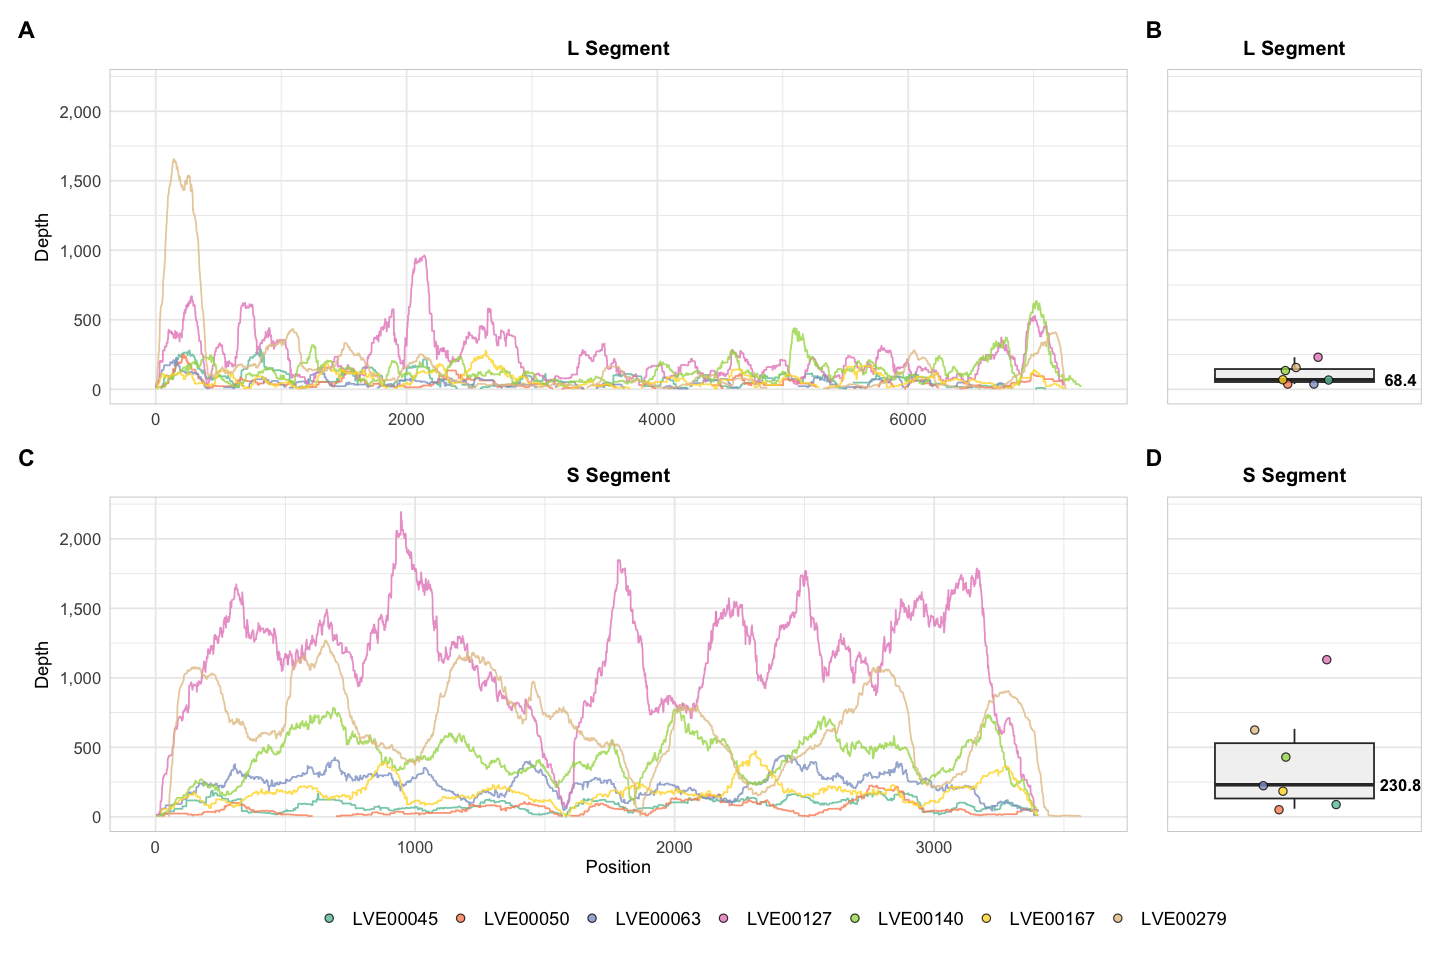

In [12]:
options(repr.plot.width=12, repr.plot.height=8)

theme_coverage <- theme_minimal(base_size = 11) +
    theme(
        plot.title = element_text(face = "bold", hjust = 0.5, size = 12),
        axis.title = element_text(size = 11),
        axis.text = element_text(size = 10),
        legend.text = element_text(size = 11),
        panel.border = element_rect(colour = "grey80", fill = NA),
        legend.position = "bottom"
    )

mean_cov_data <- coverage_data %>%
    group_by(index, reference_distance, segment, sample) %>%
    summarise(mean_depth = mean(depth, na.rm = TRUE)) %>%
    ungroup()

# Calculate median of the mean depths for labeling
segment_medians <- mean_cov_data %>%
    group_by(segment) %>%
    summarise(median_depth = median(mean_depth)) %>%
    mutate(label = round(median_depth, 1))

# Determine common Y-axis limits
max_depth <- max(c(coverage_data$depth, mean_cov_data$mean_depth), na.rm = TRUE)
y_limits <- c(1, max_depth + 1)

# L Segment Plots
p_line_L <- ggplot(filter(coverage_data, segment == "L Segment"), aes(x = POS, y = depth , color = sample)) +
    geom_line(alpha = 0.8) +
    scale_y_continuous(labels = scales::comma, name = expression("Depth"), limits = y_limits) +
    # scale_y_log10(labels = scales::comma, name = expression("Depth (log"[10]*")"), limits = y_limits) +
    scale_color_brewer(palette = "Set2") +
    guides(color = "none") +
    labs(title = "L Segment", x = NULL, color = "Sample") +
    theme_coverage

p_box_L <- ggplot(filter(mean_cov_data, segment == "L Segment"), aes(x = "", y = mean_depth)) +
    geom_boxplot(fill = "grey95", outlier.shape = NA) +
    geom_jitter(aes(fill = sample), width = 0.2, size = 2, shape = 21, alpha = 0.8) +
    geom_text(data = filter(segment_medians, segment == "L Segment"), aes(x = "", y = median_depth, label = label),
              nudge_x = 0.5, fontface = "bold", size = 3.5) +
    # scale_y_log10(labels = scales::comma, name = NULL, limits = y_limits) +
    scale_y_continuous(labels = scales::comma, name = expression("Depth"), limits = y_limits) +
    scale_fill_brewer(palette = "Set2") +
    guides(fill = "none") +
    labs(title = "L Segment", x = NULL, fill = "Sample") +
    theme_coverage +
    theme(
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        panel.grid.major.x = element_blank()
    )

# S Segment Plots
p_line_S <- ggplot(filter(coverage_data, segment == "S Segment"), aes(x = POS, y = depth, color = sample)) +
    geom_line(alpha = 0.8) +
    # scale_y_log10(labels = scales::comma, name = expression("Depth (log"[10]*")"), limits = y_limits) +
    scale_y_continuous(labels = scales::comma, name = expression("Depth"), limits = y_limits) +
    scale_color_brewer(palette = "Set2") +
    guides(color = "none") +
    labs(title = "S Segment", x = "Position", color = "Sample") +
    theme_coverage

p_box_S <- ggplot(filter(mean_cov_data, segment == "S Segment"), aes(x = "", y = mean_depth)) +
    geom_boxplot(fill = "grey95", outlier.shape = NA) +
    geom_jitter(aes(fill = sample), width = 0.2, size = 2, shape = 21, alpha = 0.8) +
    geom_text(data = filter(segment_medians, segment == "S Segment"), aes(x = "", y = median_depth, label = label),
              nudge_x = 0.5, fontface = "bold", size = 3.5) +
    # scale_y_log10(labels = scales::comma, name = NULL, limits = y_limits) +
    scale_y_continuous(labels = scales::comma, name = expression("Depth"), limits = y_limits) +
    scale_fill_brewer(palette = "Set2") +
    guides(fill = guide_legend(nrow = 1)) +
    labs(title = "S Segment", x = NULL, fill = "") +
    theme_coverage +
    theme(
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_blank(),
        axis.ticks.x = element_blank(),
        panel.grid.major.x = element_blank()
    )

# Combine plots using patchwork
p <- p_line_L  + p_box_L + p_line_S + p_box_S  +
    plot_layout(ncol = 2, widths = c(4, 1), guides = "collect") +
    plot_annotation(tag_levels = 'A') &
    theme(legend.position = "bottom", plot.tag = element_text(face = "bold", size = 14))

p
ggsave("./images/coverages.png", plot = p, width = 12, height = 8, dpi = 300)
ggsave("./../../../Fig/supplfig4.png", plot = p, width = 12, height = 8, dpi = 300)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


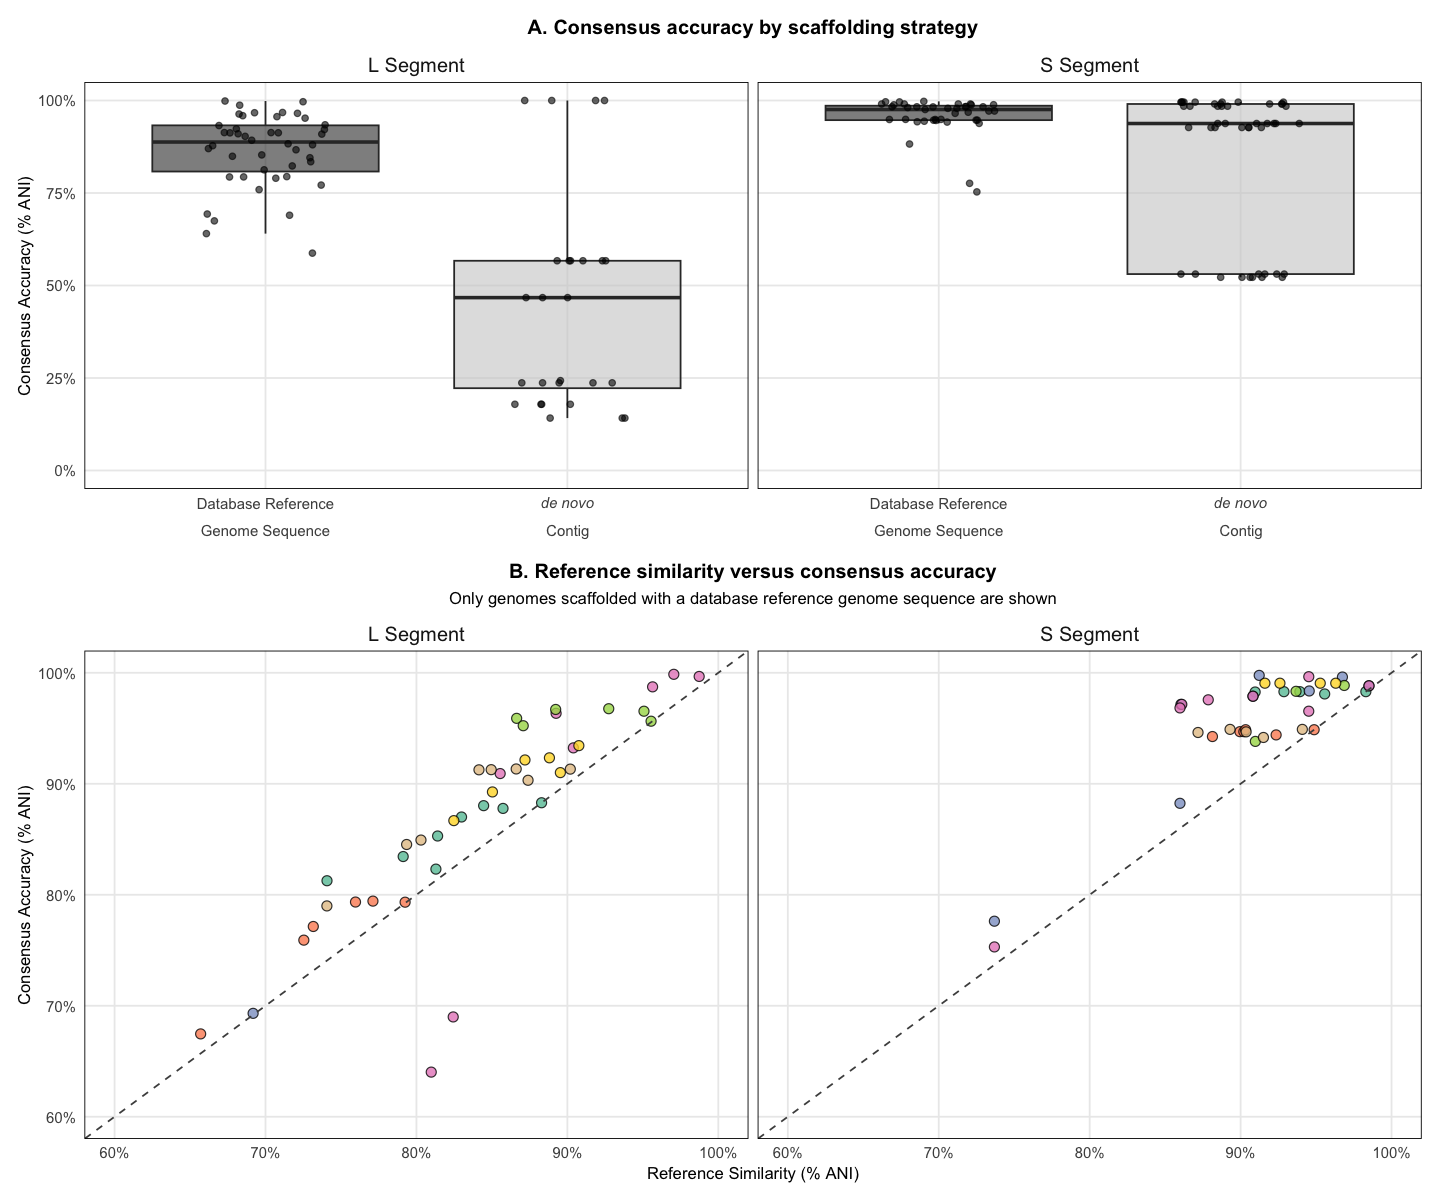

In [14]:
options(repr.plot.width=12, repr.plot.height=10)

## Alternative Figure 2: two panels with facet titles ##

plot_consensus <- consensus_vs_reference %>%
    mutate(
        scaffold_type = if_else(is_external_reference_scaffold, "Database reference genome sequence", "denovo Contig"),
        scaffold_type = factor(scaffold_type, levels = c("Database reference genome sequence", "denovo Contig")),
        segment = paste(segment, "Segment")
    ) %>%
    tidyr::drop_na(fident, matches, alignment_length)

theme_panel <- theme_minimal(base_size = 11) +
    theme(
        legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5, size = 12),
        plot.subtitle = element_text(face = "plain", hjust = 0.5, size = 10),
        axis.title = element_text(size = 10),
        axis.text = element_text(size = 9),
        strip.text = element_text(face = "plain", hjust = 0.5, size = 12),
        panel.grid.minor.x = element_blank(),
        panel.grid.minor.y = element_blank(),
        panel.border = element_rect(colour = "black", fill = NA)
    )

p_top_alt <- ggplot(
    plot_consensus,
    aes(x = scaffold_type, y = matches / alignment_length, fill = scaffold_type)
) +
    geom_boxplot(alpha = 0.6, outlier.shape = NA) +
    geom_jitter(width = 0.2, size = 1.5, alpha = 0.6) +
    scale_fill_grey() +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0, 1)) +
    scale_x_discrete(labels = c(
        "Database reference genome sequence" = expression(atop("Database Reference", "Genome Sequence")),
        "denovo Contig" = expression(atop(italic("de novo"), "Contig"))
    )) +
    facet_wrap(~segment, nrow = 1) +
    labs(
        title = "A. Consensus accuracy by scaffolding strategy",
        x = NULL,
        y = "Consensus Accuracy (% ANI)"
    ) +
    theme_panel

p_bottom_alt <- ggplot(
    filter(plot_consensus, scaffold_type == "Database reference genome sequence"),
    aes(x = fident, y = matches / alignment_length, fill = sample)
) +
    geom_point(size = 2.5, alpha = 0.8, shape = 21, color = "black") +
    geom_abline(slope = 1, intercept = 0, color = "grey30", linetype = "dashed", linewidth = 0.5) +
    scale_fill_brewer(palette = "Set2") +
    scale_x_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0.6, 1)) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), limits = c(0.6, 1)) +
    facet_wrap(~segment, nrow = 1) +
    labs(
        title = "B. Reference similarity versus consensus accuracy",
        subtitle = "Only genomes scaffolded with a database reference genome sequence are shown",
        x = "Reference Similarity (% ANI)",
        y = "Consensus Accuracy (% ANI)"
    ) +
    theme_panel

p_alt <- (p_top_alt / p_bottom_alt) +
    plot_layout(heights = c(1, 1.2))

p_alt
ggsave("./images/fig2.png", p_alt, width = 10, height = 8, dpi = 300)
ggsave("../../../Fig/fig2.png", p_alt, width = 10, height = 8, dpi = 300)